In [4]:
import torch
import numpy as np
import h5py
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from time import time

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, path_to_h5, key, channels, device=DEVICE):
        self.filepath = path_to_h5
        self.device = device
        self.key = key
        self.channels = channels
        with h5py.File(self.filepath, "r") as hf:
            self.size = hf[self.key].shape[0]

    def __len__(self):
        return self.size

    def __getitem__(self, index):
        with h5py.File(self.filepath, "r") as hf:
            im = torch.tensor(hf[self.key][index, :, :, self.channels]).to(self.device)
            # put channels first for Conv2D score model
            return torch.permute(im, (2, 0, 1))


In [6]:

dataset_path = "/home/aadam/scratch/skirt512_grizy.h5"
dataset_key = "images"
dataset_channels = [0]
batch_size = 4
shuffle = False

dataset = Dataset(dataset_path, dataset_key, dataset_channels, device=DEVICE)

# Benchmark with shuffle

In [27]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [28]:
%%timeit
for x in dataloader:
    break

885 ms ± 356 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Benchmark iterating in order

In [46]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)

In [47]:
%%timeit
for x in dataloader:
    break

20.4 ms ± 201 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Testing new idea iterating over dataset

In [66]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")

100%|██████████| 1000/1000 [05:24<00:00,  3.08it/s]

Took 324.2278172969818 seconds


Text(0.5, 0, 'Iterations')

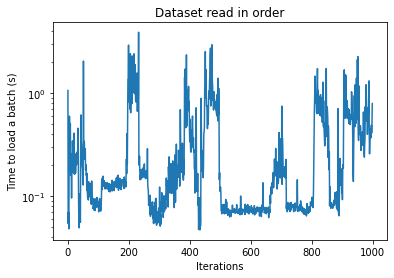

In [69]:
plt.title("Dataset read in order")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")

In [70]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")

100%|██████████| 1000/1000 [29:39<00:00,  1.78s/it]

Took 1779.8196201324463 seconds


Text(0.5, 0, 'Iterations')

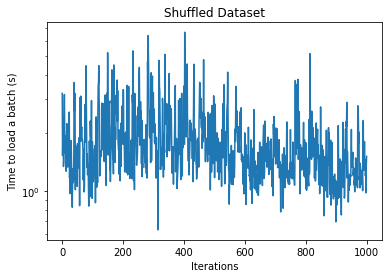

In [71]:
plt.title("Shuffled Dataset")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")

# Larger batch size

In [7]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")

100%|██████████| 1000/1000 [15:05<00:00,  1.10it/s] 

Took 905.6564910411835 seconds


Text(0.5, 0, 'Iterations')

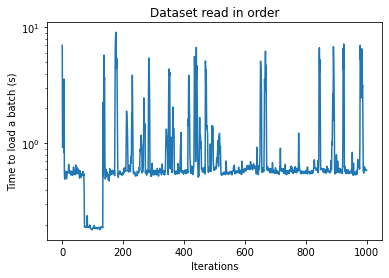

In [8]:
plt.title("Dataset read in order")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")